In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow.keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
# from keras.utils import np_utils   #np_utils
from tensorflow.keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
data_1 = pd.read_csv('t_2_11.2_50.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
#数目count、均值mean、标准差std、最小值min、下四分位数25%、中位数50%、上四分位数75%、最大值max
data_1.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
T,40000.0,2000.050030,1154.714989,0.10000,1000.075015,2000.050030,3000.025045,4000.00006
H,40000.0,0.163048,401.008617,-1510.00000,-278.000000,-5.955000,277.000000,1340.00000
Surge,40000.0,5.607178,93.005630,-373.00000,-56.400000,4.280000,64.700000,452.00000
Sway,40000.0,0.042822,2.851035,-11.10000,-1.830000,0.030350,1.900000,11.60000
Heave,40000.0,-24.376800,379.528224,-1390.00000,-285.000000,-31.600000,236.000000,1190.00000
Roll,40000.0,-0.000003,0.000376,-0.00181,-0.000251,-0.000003,0.000246,0.00183
Pitch,40000.0,-0.000050,0.018356,-0.06750,-0.012900,0.000474,0.012600,0.06840
Yaw,40000.0,0.000002,0.000222,-0.00129,-0.000136,-0.000001,0.000135,0.00131
Force1,40000.0,4994.700750,753.575930,2290.00000,4480.000000,4980.000000,5500.000000,8110.00000
Force2,40000.0,4957.142000,277.992156,4120.00000,4750.000000,4950.000000,5170.000000,5700.00000


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5])
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7])
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [5]:
print(np.hstack((H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2)))

[[-0.23649123 -0.0958     -0.02200097 ... -0.00769335 -0.09965636
   0.        ]
 [-0.22245614 -0.09637576 -0.02199577 ... -0.00779385 -0.17525773
  -0.32911392]
 [-0.20701754 -0.09272727 -0.02518943 ... -0.00752385 -0.18900344
  -0.67088608]
 ...
 [-0.08982456 -0.38666667 -0.06819383 ...  0.17461538 -0.35738832
   0.3164557 ]
 [-0.10245614 -0.39151515 -0.04343612 ...  0.15153846 -0.36426117
   0.32911392]
 [-0.11508772 -0.39151515 -0.07735683 ...  0.06130769 -0.37113402
   0.32911392]]


In [6]:
from scipy.stats import pearsonr

# 数据准备
# x = [1, 2, 3, 4, 5]
# y = [6, 7, 8, 9, 10]

# 计算相关系数和p值
corr, p_value = pearsonr(Pitch.reshape(40000,), Force1.reshape(40000,))
print("Pitch与Force1的相关系数：", corr)
print("Pitch与Force1的p值：", p_value)



corr, p_value = pearsonr(Heave.reshape(40000,), Force1.reshape(40000,))
print("Heave与Force1的相关系数：", corr)
print("Heave与Force1的p值：", p_value)


corr, p_value = pearsonr(Surge.reshape(40000,), Force1.reshape(40000,))
print("Surge与Force1的相关系数：", corr)
print("Surge与Force1的p值：", p_value)


corr, p_value = pearsonr(H.reshape(40000,), Force1.reshape(40000,))
print("H与Force1的相关系数：", corr)
print("H与Force1的p值：", p_value)

Pitch与Force1的相关系数： 0.1570448937609678
Pitch与Force1的p值： 3.224243878209501e-219
Heave与Force1的相关系数： 0.9595479237346852
Heave与Force1的p值： 0.0
Surge与Force1的相关系数： 0.9420601187541644
Surge与Force1的p值： 0.0
H与Force1的相关系数： 0.943744072470456
H与Force1的p值： 0.0


In [7]:
corr, p_value = pearsonr(Sway.reshape(40000,), Force1.reshape(40000,))
print("Sway与Force1的相关系数：", corr)
print("Sway与Force1的p值：", p_value)


corr, p_value = pearsonr(Roll.reshape(40000,), Force1.reshape(40000,))
print("Roll与Force1的相关系数：", corr)
print("Roll与Force1的p值：", p_value)


corr, p_value = pearsonr(Yaw.reshape(40000,), Force1.reshape(40000,))
print("Yaw与Force1的相关系数：", corr)
print("Yaw与Force1的p值：", p_value)

Sway与Force1的相关系数： -0.017061162868981704
Sway与Force1的p值： 0.0006439962406427817
Roll与Force1的相关系数： 0.005541442766923964
Roll与Force1的p值： 0.2677484971979654
Yaw与Force1的相关系数： -0.04017093264707763
Yaw与Force1的p值： 9.193002955695464e-16


In [8]:
corr, p_value = pearsonr(Pitch.reshape(40000,), Force2.reshape(40000,))
print("Pitch与Force2的相关系数：", corr)
print("Pitch与Force2的p值：", p_value)
corr, p_value = pearsonr(Heave.reshape(40000,), Force2.reshape(40000,))
print("Heave与Force2的相关系数：", corr)
print("Heave与Force2的p值：", p_value)
corr, p_value = pearsonr(Surge.reshape(40000,), Force2.reshape(40000,))
print("Surge与Force2的相关系数：", corr)
print("Surge与Force2的p值：", p_value)
corr, p_value = pearsonr(H.reshape(40000,), Force2.reshape(40000,))
print("H与Force2的相关系数：", corr)
print("H与Force2的p值：", p_value)
corr, p_value = pearsonr(Sway.reshape(40000,), Force2.reshape(40000,))
print("Sway与Force2的相关系数：", corr)
print("Sway与Force2的p值：", p_value)
corr, p_value = pearsonr(Roll.reshape(40000,), Force2.reshape(40000,))
print("Roll与Force2的相关系数：", corr)
print("Roll与Force2的p值：", p_value)
corr, p_value = pearsonr(Yaw.reshape(40000,), Force2.reshape(40000,))
print("Yaw与Force2的相关系数：", corr)
print("Yaw与Force2的p值：", p_value)

Pitch与Force2的相关系数： -0.5043139138077157
Pitch与Force2的p值： 0.0
Heave与Force2的相关系数： 0.6464190083043969
Heave与Force2的p值： 0.0
Surge与Force2的相关系数： 0.23961258957130266
Surge与Force2的p值： 0.0
H与Force2的相关系数： 0.6633546177230117
H与Force2的p值： 0.0
Sway与Force2的相关系数： -0.0432497340387125
Sway与Force2的p值： 4.984501462407957e-18
Roll与Force2的相关系数： -0.0009338059230854329
Roll与Force2的p值： 0.851852425853654
Yaw与Force2的相关系数： -0.015822529025764177
Yaw与Force2的p值： 0.0015529362077424701


In [9]:
# corr_pearson1 = np.corrcoef(np.hstack((H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2)), rowvar = False) #np.corrcoef指Pearson皮尔逊相关系数
# print(corr_pearson1)
# # # corr_pearson1 = scaled_data.iloc[:, 1:10].corr('pearson')
# # # print(corr_pearson1)

# import seaborn as sns
# figure, ax = plt.subplots(figsize = (10, 10))
# # figsize = (5.67, 5.67)
# #设置字体以便支持中文
# plt.rcParams['font.sans-serif']=['SimHei']
# #为正常显示负号
# plt.rcParams['axes.unicode_minus'] = False 
# #设置字体以便支持中文
# # plt.rcParams['font.sans-serif']=['SongNTR']
# sns.heatmap(corr_pearson1, square=True, annot=True, ax=ax, xticklabels = ['波高', '纵荡', '横荡', '垂荡', '横摇', '纵摇', '艏摇', '迎浪系泊', '背浪系泊'], yticklabels = ['波高', '纵荡', '横荡', '垂荡', '横摇', '纵摇', '艏摇', '迎浪系泊', '背浪系泊'], cmap='RdYlGn')  #cmap调整热力图颜色(Purples)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.show()
# plt.savefig('corr_features.tif')

In [29]:
# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    #c =abs((XP-XA)/XA)
    c1 =abs((XP1-XA1))
    #MAPE = (c.sum())/(c.shape[0])
    MAE1 = (c1.sum())/(c1.shape[0])
#     print('MAE:',MAE1)
#     print('MAE(sklearn):', mean_absolute_error(XP1, XA1))
#     print('MAPE(sklearn):', mean_absolute_percentage_error(XP1, XA1))

    #MSE
    r1 = ((XP1-XA1)*(XP1-XA1)).sum()/(XP1.shape[0])
    #RMSE = np.sqrt(r)
    MSE1 = r1
#     print('MSE:', MSE1)
#     print('MSE(sklearn):', mean_squared_error(XP1, XA1))
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))
#     #R^2
#     XM1 = XA1.sum()/(XA1.shape[0])
#     R2_1 = 1-(((XP1-XA1)*(XP1-XA1)).sum()/((XM1-XA1)*(XM1-XA1)).sum())
#     print('R^2:', R2_1)
#     print('R^2(sklearn):', r2_score(XP1, XA1))

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)
    
def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

In [11]:
# class InitCentersRandom(Initializer):
#     """ Initializer for initialization of centers of RBF network
#         as random samples from the given data set.

#     # Arguments
#         X: matrix, dataset to choose the centers from (random rows
#           are taken as centers)
#     """

#     def __init__(self, X):
#         self.X = X

#     def __call__(self, shape, dtype=None):
#         assert shape[1] == self.X.shape[1]
#         idx = np.random.randint(self.X.shape[0], size=shape[0])

# 	# type checking to access elements of data correctly
# #         if type(self.X) == np.ndarray:
# #             return self.X[idx, :]
# #         elif type(self.X) == pd.core.frame.DataFrame:
# #             return self.X.iloc[idx, :]
# class RBFLayer(Layer):
#     """ Layer of Gaussian RBF units.
#     # Example

#     ```python
#         model = Sequential()
#         model.add(RBFLayer(10,
#                            initializer=InitCentersRandom(X),
#                            betas=1.0,
#                            input_shape=(1,)))
#         model.add(Dense(1))
#     ```


#     # Arguments
#         output_dim: number of hidden units (i.e. number of outputs of the
#                     layer)
#         initializer: instance of initiliazer to initialize centers
#         betas: float, initial value for betas

#     """
#     def __init__(self, output_dim, initializer=None, betas=1.0, **kwargs):
#         self.output_dim = output_dim
#         self.init_betas = betas
#         if not initializer:
#             self.initializer = RandomUniform(0.0, 1.0)
#         else:
#             self.initializer = initializer
#         super(RBFLayer, self).__init__(**kwargs)

#     def build(self, input_shape):

#         self.centers = self.add_weight(name='centers',
#                                        shape=(self.output_dim, input_shape[1]),
#                                        initializer=self.initializer,
#                                        trainable=True)
#         self.betas = self.add_weight(name='betas',
#                                      shape=(self.output_dim,),
#                                      initializer=Constant(
#                                          value=self.init_betas),
#                                      # initializer='ones',
#                                      trainable=True)

#         super(RBFLayer, self).build(input_shape)
#     def call(self, x):

#         C = K.expand_dims(self.centers)
#         H = K.transpose(C-K.transpose(x))
#         return K.exp(-self.betas * K.sum(H**2, axis=1))

#         # C = self.centers[np.newaxis, :, :]
#         # X = x[:, np.newaxis, :]

#         # diffnorm = K.sum((C-X)**2, axis=-1)
#         # ret = K.exp( - self.betas * diffnorm)
#         # return ret

#     def compute_output_shape(self, input_shape):
#         return (input_shape[0], self.output_dim)

#     def get_config(self):
#         # have to define get_config to be able to use model_from_json
#         config = {
#             'output_dim': self.output_dim
#         }
#         base_config = super(RBFLayer, self).get_config()
#         return dict(list(base_config.items()) + list(config.items()))        
# def Model_RBF(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
#     model1 = Sequential()
#     model1.add(RBFLayer(30, initializer=InitCentersRandom(train_x), betas=2.0, input_shape=(feature_number,)))
#     model1.add(Dense(units = Dense_units, activation = 'relu', kernel_regularizer = l2(0.001)))
#     model1.add(Dense(1))
#     #model.compile()用来配置学习过程 #优化器选用adam，损失函数选用均方误差
#     adam = Adam(lr=0.001)
#     model1.compile(optimizer = 'adam' , loss = 'mse') 
#     history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
#     model_structure = model.summary()
#     pre_train_Y = model.predict(train_X)
#     pre_Y = model.predict(valid_X)
#     return history, pre_train_Y, pre_Y


def Model_NN(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return history, pre_train_Y, pre_Y


# 基于直方图的梯度增强回归树（Histogram-based Gradient Boosting Regression Tree, HGBRT）
from sklearn.experimental import enable_hist_gradient_boosting 
from sklearn.ensemble import HistGradientBoostingRegressor
max_depth=[3, 5, 6, 7, 9, 12, 15, 17, 25]
# max_leaf_nodes=[29, 30, 31, 32, 33]
# min_samples_leaf=[18, 19, 20, 21, 22]
max_leaf_nodes=[i for i in range(25, 45)]
min_samples_leaf=[i for i in range(10, 25)]
def HGBRT(train_x, train_y,valid_x,max_depth,max_leaf_nodes,min_samples_leaf):
    param_grid = dict(max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_leaf=min_samples_leaf)
    grid_search = GridSearchCV(HistGradientBoostingRegressor(), param_grid, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid_result = grid_search.fit(train_x, train_y)
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    best_parameters = grid_search.best_estimator_.get_params()
    best_model = HistGradientBoostingRegressor(learning_rate=0.1,
                                               max_depth=best_parameters['max_depth'],
                                               max_leaf_nodes=best_parameters['max_leaf_nodes'],
                                               min_samples_leaf=best_parameters['min_samples_leaf'],
                                               loss='least_squares')
    best_model.fit(train_x, train_y)
    pre_y = best_model.predict(valid_x)
    pre_y = best_model.predict(valid_x)
    return pre_y, best_parameters


from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
max_depth=[3, 5, 7, 9, 11, 13, 15]
min_child_weight=[1, 3]
gamma=[0, 0.05, 0.1]
subsample=[0.6, 0.7, 0.8, 0.9, 1]
colsample_bytree=[0.6, 0.7, 0.8, 0.9, 1]
reg_alpha=[0, 0.001, 0.005, 0.025, 0.05]
learning_rate=[0.025, 0.05, 0.1, 0.2]
n_estimators=[50, 100, 200, 400]
# 分布式梯度增强树
def XGBoost(train_x,train_y,valid_x,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,learning_rate,n_estimators):
#     max_depth=3,min_child_weight=1,gamma=0,subsample=0.6,colsample_bytree=0.6,reg_alpha=0.001,learning_rate=0.001,n_estimators=100
    # 参数调优部分(网格调优)
    param_grid = dict(max_depth=max_depth,
                min_child_weight=min_child_weight,
                gamma=gamma,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                reg_alpha=reg_alpha,
                learning_rate=learning_rate,
                n_estimators=n_estimators)
    grid_search = GridSearchCV(XGBRegressor(), param_grid, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid_result = grid_search.fit(train_x, train_y)
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print("%f (%f) with: %r" % (mean, stdev, param))
    best_parameters = grid_search.best_estimator_.get_params()
    # 使用模型对测试集数据进行预测
    best_model = XGBRegressor(max_depth=best_parameters['max_depth'],
                              min_child_weight=best_parameters['min_child_weight'],
                              gamma=best_parameters['gamma'],
                              subsample=best_parameters['subsample'],
                              colsample_bytree=best_parameters['colsample_bytree'],
                              reg_alpha=best_parameters['reg_alpha'],
                              learning_rate=best_parameters['learning_rate'],
                              n_estimators=best_parameters['n_estimators'])
    best_model.fit(train_x,train_y)
    pre_y = best_model.predict(valid_x)
    return pre_y, best_parameters

In [12]:
# 不同非线性模型下的效果
train_x, train_y, valid_x, valid_y= split_train_valid(np.hstack((Surge,Pitch,Heave)), Force1, 20000, 30000, 31000)

# R_history, R_pre_train_Y, R_pre_Y = Model_RBF(train_x, train_y, valid_x, valid_y, feature_number, lr=0.01, epochs=1000, batch_size=256)
N_history, N_pre_train_Y, N_pre_Y = Model_NN(train_x, train_y, valid_x, valid_y, 3, lr=0.01, epochs=1000, batch_size=256)
# X_pre_y, X_best_parameters = XGBoost(train_x, train_y, valid_x,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,learning_rate,n_estimators)
H_pre_y, H_best_parameters = HGBRT(train_x, train_y, valid_x,max_depth,max_leaf_nodes,min_samples_leaf)

Train on 10000 samples, validate on 1000 samples
Epoch 1/1000
 - 0s - loss: 0.0070 - val_loss: 2.9051e-04
Epoch 2/1000
 - 0s - loss: 1.9407e-04 - val_loss: 2.6546e-05
Epoch 3/1000
 - 0s - loss: 3.3593e-05 - val_loss: 2.6541e-05
Epoch 4/1000
 - 0s - loss: 2.1797e-05 - val_loss: 1.8592e-05
Epoch 5/1000
 - 0s - loss: 3.1879e-05 - val_loss: 2.4348e-05
Epoch 6/1000
 - 0s - loss: 5.0122e-05 - val_loss: 2.4946e-05
Epoch 7/1000
 - 0s - loss: 7.5394e-05 - val_loss: 1.8336e-05
Epoch 8/1000
 - 0s - loss: 8.3027e-05 - val_loss: 2.4401e-05
Epoch 9/1000
 - 0s - loss: 6.3241e-05 - val_loss: 2.2702e-05
Epoch 10/1000
 - 0s - loss: 3.8907e-05 - val_loss: 1.8568e-05
Epoch 11/1000
 - 0s - loss: 3.3323e-05 - val_loss: 2.1117e-05
Epoch 12/1000
 - 0s - loss: 3.5285e-05 - val_loss: 2.8551e-05
Epoch 13/1000
 - 0s - loss: 4.0446e-05 - val_loss: 4.1814e-05
Epoch 14/1000
 - 0s - loss: 4.7667e-05 - val_loss: 5.6731e-05
Epoch 15/1000
 - 0s - loss: 6.0253e-05 - val_loss: 6.9372e-05
Epoch 16/1000
 - 0s - loss: 8.1534

 - 0s - loss: 3.3876e-05 - val_loss: 2.1929e-05
Epoch 133/1000
 - 0s - loss: 3.4711e-05 - val_loss: 2.1846e-05
Epoch 134/1000
 - 0s - loss: 3.5260e-05 - val_loss: 2.1814e-05
Epoch 135/1000
 - 0s - loss: 3.5495e-05 - val_loss: 2.1805e-05
Epoch 136/1000
 - 0s - loss: 3.5476e-05 - val_loss: 2.1786e-05
Epoch 137/1000
 - 0s - loss: 3.5316e-05 - val_loss: 2.1735e-05
Epoch 138/1000
 - 0s - loss: 3.5132e-05 - val_loss: 2.1649e-05
Epoch 139/1000
 - 0s - loss: 3.4996e-05 - val_loss: 2.1535e-05
Epoch 140/1000
 - 0s - loss: 3.4931e-05 - val_loss: 2.1406e-05
Epoch 141/1000
 - 0s - loss: 3.4924e-05 - val_loss: 2.1271e-05
Epoch 142/1000
 - 0s - loss: 3.4950e-05 - val_loss: 2.1135e-05
Epoch 143/1000
 - 0s - loss: 3.4989e-05 - val_loss: 2.1001e-05
Epoch 144/1000
 - 0s - loss: 3.5024e-05 - val_loss: 2.0870e-05
Epoch 145/1000
 - 0s - loss: 3.5045e-05 - val_loss: 2.0744e-05
Epoch 146/1000
 - 0s - loss: 3.5047e-05 - val_loss: 2.0621e-05
Epoch 147/1000
 - 0s - loss: 3.5027e-05 - val_loss: 2.0501e-05
Epoch 1

Epoch 263/1000
 - 0s - loss: 2.4430e-05 - val_loss: 2.4380e-05
Epoch 264/1000
 - 0s - loss: 2.4079e-05 - val_loss: 2.4318e-05
Epoch 265/1000
 - 0s - loss: 2.4154e-05 - val_loss: 2.4426e-05
Epoch 266/1000
 - 0s - loss: 2.4597e-05 - val_loss: 2.4621e-05
Epoch 267/1000
 - 0s - loss: 2.5072e-05 - val_loss: 2.4820e-05
Epoch 268/1000
 - 0s - loss: 2.5546e-05 - val_loss: 2.5036e-05
Epoch 269/1000
 - 0s - loss: 2.5947e-05 - val_loss: 2.5226e-05
Epoch 270/1000
 - 0s - loss: 2.6265e-05 - val_loss: 2.5387e-05
Epoch 271/1000
 - 0s - loss: 2.6489e-05 - val_loss: 2.5511e-05
Epoch 272/1000
 - 0s - loss: 2.6623e-05 - val_loss: 2.5593e-05
Epoch 273/1000
 - 0s - loss: 2.6694e-05 - val_loss: 2.5643e-05
Epoch 274/1000
 - 0s - loss: 2.6706e-05 - val_loss: 2.5670e-05
Epoch 275/1000
 - 0s - loss: 2.6717e-05 - val_loss: 2.5686e-05
Epoch 276/1000
 - 0s - loss: 2.6779e-05 - val_loss: 2.5766e-05
Epoch 277/1000
 - 0s - loss: 2.6876e-05 - val_loss: 2.5941e-05
Epoch 278/1000
 - 0s - loss: 2.7668e-05 - val_loss: 2.6

 - 0s - loss: 1.9689e-05 - val_loss: 1.9698e-05
Epoch 394/1000
 - 0s - loss: 1.9773e-05 - val_loss: 1.9766e-05
Epoch 395/1000
 - 0s - loss: 1.9906e-05 - val_loss: 1.9826e-05
Epoch 396/1000
 - 0s - loss: 2.0080e-05 - val_loss: 1.9883e-05
Epoch 397/1000
 - 0s - loss: 2.0290e-05 - val_loss: 1.9937e-05
Epoch 398/1000
 - 0s - loss: 2.0533e-05 - val_loss: 1.9990e-05
Epoch 399/1000
 - 0s - loss: 2.0806e-05 - val_loss: 2.0044e-05
Epoch 400/1000
 - 0s - loss: 2.1105e-05 - val_loss: 2.0100e-05
Epoch 401/1000
 - 0s - loss: 2.1422e-05 - val_loss: 2.0159e-05
Epoch 402/1000
 - 0s - loss: 2.1747e-05 - val_loss: 2.0219e-05
Epoch 403/1000
 - 0s - loss: 2.2070e-05 - val_loss: 2.0281e-05
Epoch 404/1000
 - 0s - loss: 2.2379e-05 - val_loss: 2.0342e-05
Epoch 405/1000
 - 0s - loss: 2.2666e-05 - val_loss: 2.0400e-05
Epoch 406/1000
 - 0s - loss: 2.2924e-05 - val_loss: 2.0454e-05
Epoch 407/1000
 - 0s - loss: 2.3149e-05 - val_loss: 2.0501e-05
Epoch 408/1000
 - 0s - loss: 2.3339e-05 - val_loss: 2.0540e-05
Epoch 4

Epoch 524/1000
 - 0s - loss: 1.9958e-05 - val_loss: 1.6375e-05
Epoch 525/1000
 - 0s - loss: 2.0112e-05 - val_loss: 1.6360e-05
Epoch 526/1000
 - 0s - loss: 2.0248e-05 - val_loss: 1.6348e-05
Epoch 527/1000
 - 0s - loss: 2.0370e-05 - val_loss: 1.6336e-05
Epoch 528/1000
 - 0s - loss: 2.0480e-05 - val_loss: 1.6324e-05
Epoch 529/1000
 - 0s - loss: 2.0575e-05 - val_loss: 1.6313e-05
Epoch 530/1000
 - 0s - loss: 2.0658e-05 - val_loss: 1.6301e-05
Epoch 531/1000
 - 0s - loss: 2.0729e-05 - val_loss: 1.6291e-05
Epoch 532/1000
 - 0s - loss: 2.0790e-05 - val_loss: 1.6281e-05
Epoch 533/1000
 - 0s - loss: 2.0840e-05 - val_loss: 1.6271e-05
Epoch 534/1000
 - 0s - loss: 2.0879e-05 - val_loss: 1.6262e-05
Epoch 535/1000
 - 0s - loss: 2.0907e-05 - val_loss: 1.6254e-05
Epoch 536/1000
 - 0s - loss: 2.0924e-05 - val_loss: 1.6247e-05
Epoch 537/1000
 - 0s - loss: 2.0932e-05 - val_loss: 1.6240e-05
Epoch 538/1000
 - 0s - loss: 2.0935e-05 - val_loss: 1.6234e-05
Epoch 539/1000
 - 0s - loss: 2.0935e-05 - val_loss: 1.6

...

Epoch 785/1000
 - 0s - loss: 1.8698e-05 - val_loss: 1.6663e-05
Epoch 786/1000
 - 0s - loss: 1.8974e-05 - val_loss: 1.6707e-05
Epoch 787/1000
 - 0s - loss: 1.9294e-05 - val_loss: 1.6739e-05
Epoch 788/1000
 - 0s - loss: 1.9643e-05 - val_loss: 1.6763e-05
Epoch 789/1000
 - 0s - loss: 2.0013e-05 - val_loss: 1.6770e-05
Epoch 790/1000
 - 0s - loss: 2.0377e-05 - val_loss: 1.6756e-05
Epoch 791/1000
 - 0s - loss: 2.0698e-05 - val_loss: 1.6731e-05
Epoch 792/1000
 - 0s - loss: 2.0948e-05 - val_loss: 1.6709e-05
Epoch 793/1000
 - 0s - loss: 2.1126e-05 - val_loss: 1.6693e-05
Epoch 794/1000
 - 0s - loss: 2.1241e-05 - val_loss: 1.6671e-05
Epoch 795/1000
 - 0s - loss: 2.1266e-05 - val_loss: 1.6635e-05
Epoch 796/1000
 - 0s - loss: 2.1186e-05 - val_loss: 1.6590e-05
Epoch 797/1000
 - 0s - loss: 2.0958e-05 - val_loss: 1.6488e-05
Epoch 798/1000
 - 0s - loss: 2.0579e-05 - val_loss: 1.6553e-05
Epoch 799/1000
 - 0s - loss: 2.0530e-05 - val_loss: 1.6656e-05
Epoch 800/1000
 - 0s - loss: 2.0620e-05 - val_loss: 1.6

 - 0s - loss: 1.7231e-05 - val_loss: 1.6020e-05
Epoch 916/1000
 - 0s - loss: 1.7181e-05 - val_loss: 1.6110e-05
Epoch 917/1000
 - 0s - loss: 1.7322e-05 - val_loss: 1.6130e-05
Epoch 918/1000
 - 0s - loss: 1.7427e-05 - val_loss: 1.6175e-05
Epoch 919/1000
 - 0s - loss: 1.7543e-05 - val_loss: 1.6221e-05
Epoch 920/1000
 - 0s - loss: 1.7689e-05 - val_loss: 1.6259e-05
Epoch 921/1000
 - 0s - loss: 1.7848e-05 - val_loss: 1.6297e-05
Epoch 922/1000
 - 0s - loss: 1.8027e-05 - val_loss: 1.6331e-05
Epoch 923/1000
 - 0s - loss: 1.8227e-05 - val_loss: 1.6361e-05
Epoch 924/1000
 - 0s - loss: 1.8444e-05 - val_loss: 1.6387e-05
Epoch 925/1000
 - 0s - loss: 1.8678e-05 - val_loss: 1.6411e-05
Epoch 926/1000
 - 0s - loss: 1.8924e-05 - val_loss: 1.6434e-05
Epoch 927/1000
 - 0s - loss: 1.9174e-05 - val_loss: 1.6457e-05
Epoch 928/1000
 - 0s - loss: 1.9419e-05 - val_loss: 1.6478e-05
Epoch 929/1000
 - 0s - loss: 1.9648e-05 - val_loss: 1.6494e-05
Epoch 930/1000
 - 0s - loss: 1.9862e-05 - val_loss: 1.6505e-05
Epoch 9

D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Best: -0.006682 using {'max_depth': 15, 'max_leaf_nodes': 43, 'min_samples_leaf': 20}


D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


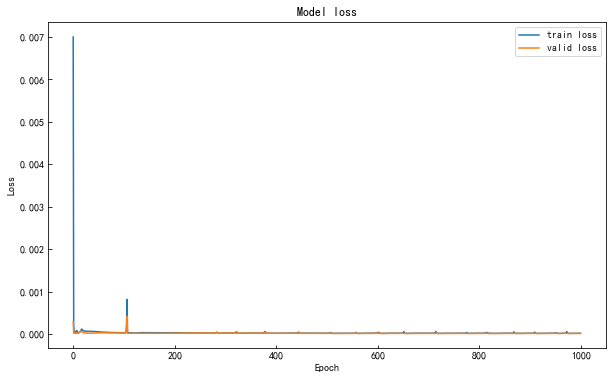

[[6.99948397e-03 2.90509243e-04]
 [1.94069762e-04 2.65457919e-05]
 [3.35932534e-05 2.65409348e-05]
 ...
 [1.97457023e-05 1.65831428e-05]
 [1.97729293e-05 1.65722081e-05]
 [1.98001930e-05 1.65648980e-05]]


In [13]:
# loss_plot(R_history, epo=1000, length=10, width=6)
loss_plot(N_history, epo=1000, length=10, width=6)

In [14]:
print(N_pre_Y.shape)
print(H_pre_y.shape)


(1000, 1)
(1000,)


RMSE(sklearn): 0.004069999741823512
Acc: 0.9974081638469094
RMSE(sklearn): 0.007244716700045015
Acc: 0.9963980882262893


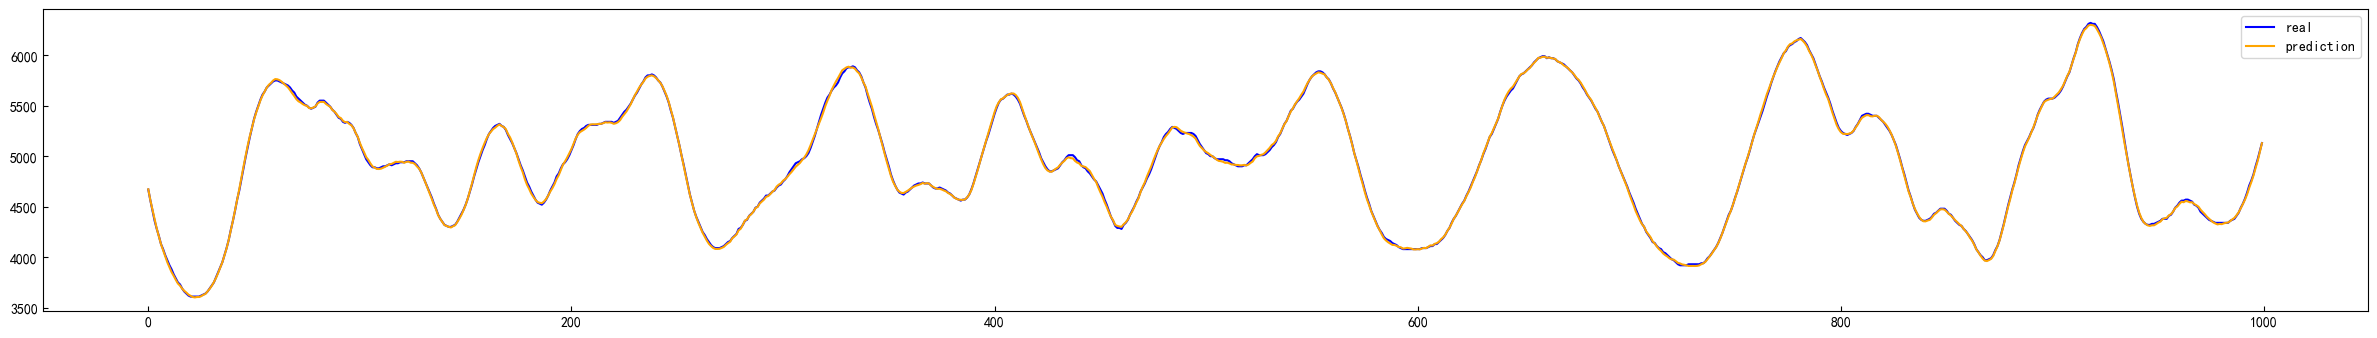

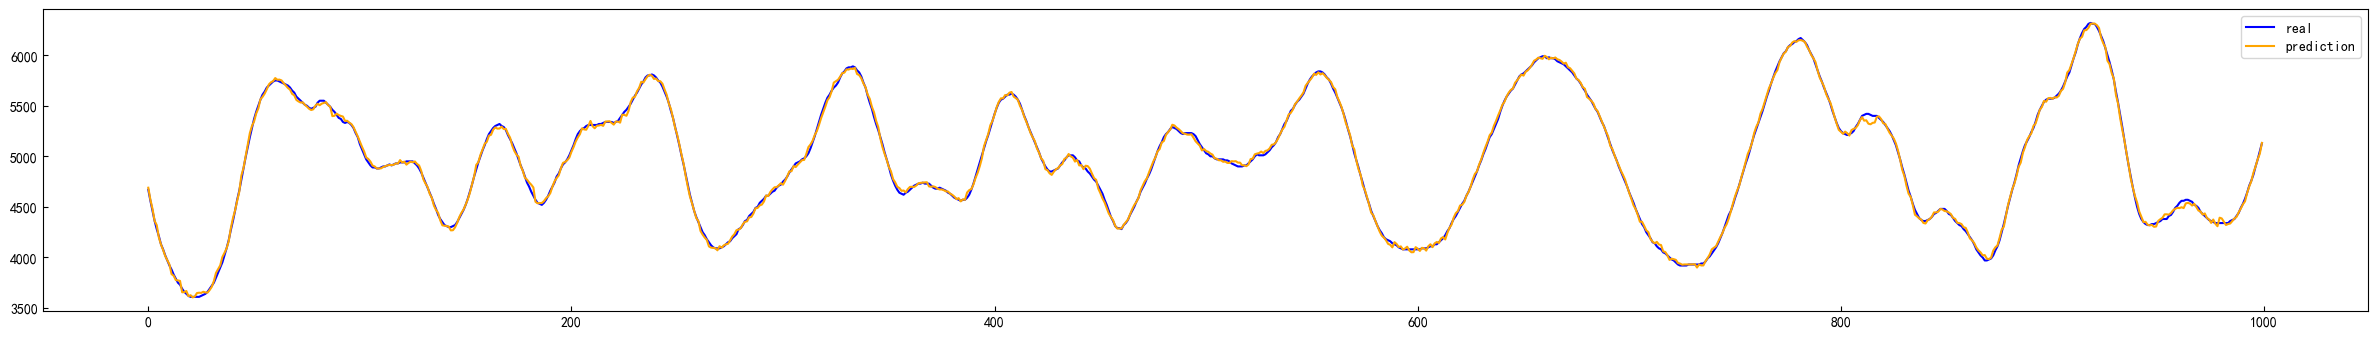

In [30]:
# evaluate(valid_y,pre_Y)
# evaluate(valid_y,R_pre_Y)
evaluate(valid_y,N_pre_Y)
evaluate(valid_y,H_pre_y)
# evaluate(valid_y,X_pre_y)
# print(valid_y)

# print(R_pre_Y)

# print(N_pre_Y)

# print(H_pre_y)

# print(H_pre_y)
fan1_force1_real,fan1_force1_pre = FanGuiHua_force1(valid_y,N_pre_Y)
np.savetxt('Force1_非线性_NN.csv',np.hstack((fan1_force1_real,fan1_force1_pre)),delimiter=',')
fan2_force1_real,fan2_force1_pre = FanGuiHua_force1(valid_y,H_pre_y.reshape(1000,1))
np.savetxt('Force1_非线性_HGBRT.csv',np.hstack((fan2_force1_real,fan2_force1_pre)),delimiter=',')

In [34]:
def campare(first,end):
    value = 100*(end-first)/first
    return print(value,'%')

campare(0.007244716700045015,0.004069999741823512)
campare(0.9963980882262893,0.9974081638469094)

-43.821133243233334 %
0.10137269757494456 %


In [17]:
# plt.figure(figsize=(60, 4), dpi=100)
# plt.plot(valid_y, color='blue', label = 'real')   #真实曲线
# plt.plot(R_pre_Y, color='orange', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

# plt.figure(figsize=(60, 4), dpi=100)
# plt.plot(valid_y, color='blue', label = 'real')   #真实曲线
# plt.plot(N_pre_Y, color='orange', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

# plt.figure(figsize=(60, 4), dpi=100)
# plt.plot(valid_y, color='blue', label = 'real')   #真实曲线
# plt.plot(H_pre_y, color='orange', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

# plt.figure(figsize=(60, 4), dpi=100)
# plt.plot(valid_y, color='blue', label = 'real')   #真实曲线
# plt.plot(X_pre_Y, color='orange', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

In [18]:
# 不同非线性模型下的效果
train_x_Force2, train_y_Force2, valid_x_Force2, valid_y_Force2= split_train_valid(np.hstack((Surge,Pitch,Heave)), Force2, 20000, 30000, 31000)

# R_history_Force2, R_pre_train_Y_Force2, R_pre_Y_Force2 = Model_RBF(train_x_Force2, train_y_Force2, valid_x_Force2, valid_y_Force2, feature_number, lr=0.01, epochs=1000, batch_size=256)
N_history_Force2, N_pre_train_Y_Force2, N_pre_Y_Force2 = Model_NN(train_x_Force2, train_y_Force2, valid_x_Force2, valid_y_Force2, 3, lr=0.01, epochs=1000, batch_size=256)
# X_pre_y_Force2 X_best_parameters_Force2= XGBoost(train_x_Force2, train_y_Force2, valid_x_Force2,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,learning_rate,n_estimators)
H_pre_y_Force2, H_best_parameters_Force2= HGBRT(train_x_Force2, train_y_Force2, valid_x_Force2,max_depth,max_leaf_nodes,min_samples_leaf)

Train on 10000 samples, validate on 1000 samples
Epoch 1/1000
 - 0s - loss: 0.0160 - val_loss: 0.0012
Epoch 2/1000
 - 0s - loss: 4.4855e-04 - val_loss: 2.3779e-04
Epoch 3/1000
 - 0s - loss: 2.5299e-04 - val_loss: 2.3438e-04
Epoch 4/1000
 - 0s - loss: 3.0173e-04 - val_loss: 2.2540e-04
Epoch 5/1000
 - 0s - loss: 4.1401e-04 - val_loss: 2.6676e-04
Epoch 6/1000
 - 0s - loss: 3.6722e-04 - val_loss: 2.3791e-04
Epoch 7/1000
 - 0s - loss: 2.8051e-04 - val_loss: 2.2531e-04
Epoch 8/1000
 - 0s - loss: 2.5524e-04 - val_loss: 2.2647e-04
Epoch 9/1000
 - 0s - loss: 2.5958e-04 - val_loss: 2.2560e-04
Epoch 10/1000
 - 0s - loss: 2.7267e-04 - val_loss: 2.2938e-04
Epoch 11/1000
 - 0s - loss: 3.1848e-04 - val_loss: 2.4958e-04
Epoch 12/1000
 - 0s - loss: 4.2795e-04 - val_loss: 2.9343e-04
Epoch 13/1000
 - 0s - loss: 5.0450e-04 - val_loss: 3.0610e-04
Epoch 14/1000
 - 0s - loss: 4.6725e-04 - val_loss: 2.8319e-04
Epoch 15/1000
 - 0s - loss: 4.0629e-04 - val_loss: 2.7038e-04
Epoch 16/1000
 - 0s - loss: 3.7997e-04

 - 0s - loss: 2.4847e-04 - val_loss: 2.1766e-04
Epoch 133/1000
 - 0s - loss: 2.4835e-04 - val_loss: 2.1815e-04
Epoch 134/1000
 - 0s - loss: 2.4856e-04 - val_loss: 2.1867e-04
Epoch 135/1000
 - 0s - loss: 2.4897e-04 - val_loss: 2.1917e-04
Epoch 136/1000
 - 0s - loss: 2.4946e-04 - val_loss: 2.1964e-04
Epoch 137/1000
 - 0s - loss: 2.4993e-04 - val_loss: 2.2008e-04
Epoch 138/1000
 - 0s - loss: 2.5031e-04 - val_loss: 2.2048e-04
Epoch 139/1000
 - 0s - loss: 2.5054e-04 - val_loss: 2.2087e-04
Epoch 140/1000
 - 0s - loss: 2.5062e-04 - val_loss: 2.2126e-04
Epoch 141/1000
 - 0s - loss: 2.5053e-04 - val_loss: 2.2165e-04
Epoch 142/1000
 - 0s - loss: 2.5029e-04 - val_loss: 2.2206e-04
Epoch 143/1000
 - 0s - loss: 2.4995e-04 - val_loss: 2.2247e-04
Epoch 144/1000
 - 0s - loss: 2.4952e-04 - val_loss: 2.2289e-04
Epoch 145/1000
 - 0s - loss: 2.4903e-04 - val_loss: 2.2331e-04
Epoch 146/1000
 - 0s - loss: 2.4851e-04 - val_loss: 2.2369e-04
Epoch 147/1000
 - 0s - loss: 2.4797e-04 - val_loss: 2.2403e-04
Epoch 1

Epoch 263/1000
 - 0s - loss: 2.1670e-04 - val_loss: 2.0115e-04
Epoch 264/1000
 - 0s - loss: 2.1597e-04 - val_loss: 2.0082e-04
Epoch 265/1000
 - 0s - loss: 2.1492e-04 - val_loss: 2.0042e-04
Epoch 266/1000
 - 0s - loss: 2.1355e-04 - val_loss: 2.0025e-04
Epoch 267/1000
 - 0s - loss: 2.1221e-04 - val_loss: 2.0021e-04
Epoch 268/1000
 - 0s - loss: 2.1091e-04 - val_loss: 2.0028e-04
Epoch 269/1000
 - 0s - loss: 2.1008e-04 - val_loss: 2.0035e-04
Epoch 270/1000
 - 0s - loss: 2.0956e-04 - val_loss: 2.0045e-04
Epoch 271/1000
 - 0s - loss: 2.0929e-04 - val_loss: 2.0053e-04
Epoch 272/1000
 - 0s - loss: 2.0912e-04 - val_loss: 2.0061e-04
Epoch 273/1000
 - 0s - loss: 2.0899e-04 - val_loss: 2.0067e-04
Epoch 274/1000
 - 0s - loss: 2.0886e-04 - val_loss: 2.0072e-04
Epoch 275/1000
 - 0s - loss: 2.0872e-04 - val_loss: 2.0078e-04
Epoch 276/1000
 - 0s - loss: 2.0859e-04 - val_loss: 2.0084e-04
Epoch 277/1000
 - 0s - loss: 2.0843e-04 - val_loss: 2.0089e-04
Epoch 278/1000
 - 0s - loss: 2.0831e-04 - val_loss: 2.0

 - 0s - loss: 1.9770e-04 - val_loss: 2.0088e-04
Epoch 394/1000
 - 0s - loss: 1.9749e-04 - val_loss: 2.0069e-04
Epoch 395/1000
 - 0s - loss: 1.9740e-04 - val_loss: 2.0068e-04
Epoch 396/1000
 - 0s - loss: 1.9724e-04 - val_loss: 2.0032e-04
Epoch 397/1000
 - 0s - loss: 1.9719e-04 - val_loss: 2.0047e-04
Epoch 398/1000
 - 0s - loss: 1.9723e-04 - val_loss: 2.0040e-04
Epoch 399/1000
 - 0s - loss: 1.9701e-04 - val_loss: 2.0013e-04
Epoch 400/1000
 - 0s - loss: 1.9693e-04 - val_loss: 2.0018e-04
Epoch 401/1000
 - 0s - loss: 1.9677e-04 - val_loss: 2.0010e-04
Epoch 402/1000
 - 0s - loss: 1.9664e-04 - val_loss: 1.9995e-04
Epoch 403/1000
 - 0s - loss: 1.9648e-04 - val_loss: 1.9987e-04
Epoch 404/1000
 - 0s - loss: 1.9632e-04 - val_loss: 1.9965e-04
Epoch 405/1000
 - 0s - loss: 1.9638e-04 - val_loss: 1.9970e-04
Epoch 406/1000
 - 0s - loss: 1.9642e-04 - val_loss: 1.9974e-04
Epoch 407/1000
 - 0s - loss: 1.9636e-04 - val_loss: 1.9978e-04
Epoch 408/1000
 - 0s - loss: 1.9629e-04 - val_loss: 1.9941e-04
Epoch 4

Epoch 524/1000
 - 0s - loss: 1.9109e-04 - val_loss: 1.9784e-04
Epoch 525/1000
 - 0s - loss: 1.9064e-04 - val_loss: 1.9772e-04
Epoch 526/1000
 - 0s - loss: 1.9061e-04 - val_loss: 1.9779e-04
Epoch 527/1000
 - 0s - loss: 1.9046e-04 - val_loss: 1.9777e-04
Epoch 528/1000
 - 0s - loss: 1.9078e-04 - val_loss: 1.9779e-04
Epoch 529/1000
 - 0s - loss: 1.9043e-04 - val_loss: 1.9774e-04
Epoch 530/1000
 - 0s - loss: 1.9041e-04 - val_loss: 1.9779e-04
Epoch 531/1000
 - 0s - loss: 1.9033e-04 - val_loss: 1.9776e-04
Epoch 532/1000
 - 0s - loss: 1.9046e-04 - val_loss: 1.9774e-04
Epoch 533/1000
 - 0s - loss: 1.9033e-04 - val_loss: 1.9771e-04
Epoch 534/1000
 - 0s - loss: 1.9016e-04 - val_loss: 1.9769e-04
Epoch 535/1000
 - 0s - loss: 1.9015e-04 - val_loss: 1.9771e-04
Epoch 536/1000
 - 0s - loss: 1.9031e-04 - val_loss: 1.9780e-04
Epoch 537/1000
 - 0s - loss: 1.9047e-04 - val_loss: 1.9790e-04
Epoch 538/1000
 - 0s - loss: 1.9087e-04 - val_loss: 1.9799e-04
Epoch 539/1000
 - 0s - loss: 1.9094e-04 - val_loss: 1.9

...

Epoch 785/1000
 - 0s - loss: 1.8538e-04 - val_loss: 2.0029e-04
Epoch 786/1000
 - 0s - loss: 1.8527e-04 - val_loss: 2.0019e-04
Epoch 787/1000
 - 0s - loss: 1.8512e-04 - val_loss: 2.0029e-04
Epoch 788/1000
 - 0s - loss: 1.8520e-04 - val_loss: 2.0007e-04
Epoch 789/1000
 - 0s - loss: 1.8535e-04 - val_loss: 2.0020e-04
Epoch 790/1000
 - 0s - loss: 1.8545e-04 - val_loss: 2.0031e-04
Epoch 791/1000
 - 0s - loss: 1.8532e-04 - val_loss: 2.0047e-04
Epoch 792/1000
 - 0s - loss: 1.8521e-04 - val_loss: 2.0014e-04
Epoch 793/1000
 - 0s - loss: 1.8513e-04 - val_loss: 2.0021e-04
Epoch 794/1000
 - 0s - loss: 1.8521e-04 - val_loss: 2.0009e-04
Epoch 795/1000
 - 0s - loss: 1.8538e-04 - val_loss: 2.0009e-04
Epoch 796/1000
 - 0s - loss: 1.8548e-04 - val_loss: 2.0033e-04
Epoch 797/1000
 - 0s - loss: 1.8546e-04 - val_loss: 2.0022e-04
Epoch 798/1000
 - 0s - loss: 1.8521e-04 - val_loss: 2.0052e-04
Epoch 799/1000
 - 0s - loss: 1.8505e-04 - val_loss: 2.0018e-04
Epoch 800/1000
 - 0s - loss: 1.8506e-04 - val_loss: 2.0

 - 0s - loss: 1.8389e-04 - val_loss: 2.0057e-04
Epoch 916/1000
 - 0s - loss: 1.8364e-04 - val_loss: 2.0061e-04
Epoch 917/1000
 - 0s - loss: 1.8344e-04 - val_loss: 2.0083e-04
Epoch 918/1000
 - 0s - loss: 1.8357e-04 - val_loss: 2.0062e-04
Epoch 919/1000
 - 0s - loss: 1.8385e-04 - val_loss: 2.0053e-04
Epoch 920/1000
 - 0s - loss: 1.8399e-04 - val_loss: 2.0058e-04
Epoch 921/1000
 - 0s - loss: 1.8404e-04 - val_loss: 2.0083e-04
Epoch 922/1000
 - 0s - loss: 1.8371e-04 - val_loss: 2.0090e-04
Epoch 923/1000
 - 0s - loss: 1.8343e-04 - val_loss: 2.0056e-04
Epoch 924/1000
 - 0s - loss: 1.8356e-04 - val_loss: 2.0051e-04
Epoch 925/1000
 - 0s - loss: 1.8380e-04 - val_loss: 2.0029e-04
Epoch 926/1000
 - 0s - loss: 1.8411e-04 - val_loss: 2.0037e-04
Epoch 927/1000
 - 0s - loss: 1.8414e-04 - val_loss: 2.0057e-04
Epoch 928/1000
 - 0s - loss: 1.8380e-04 - val_loss: 2.0088e-04
Epoch 929/1000
 - 0s - loss: 1.8333e-04 - val_loss: 2.0079e-04
Epoch 930/1000
 - 0s - loss: 1.8331e-04 - val_loss: 2.0066e-04
Epoch 9

D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Best: -0.027162 using {'max_depth': 13, 'max_leaf_nodes': 44, 'min_samples_leaf': 22}


D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


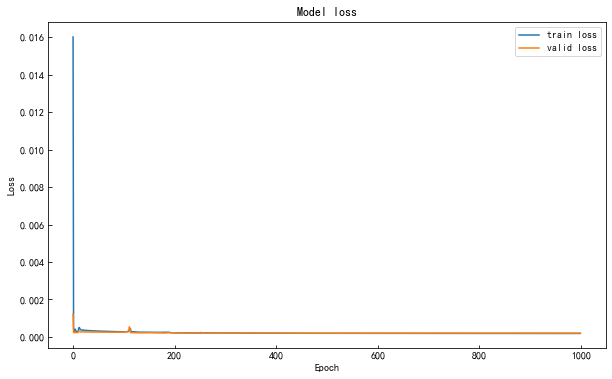

[[0.01601172 0.001219  ]
 [0.00044855 0.00023779]
 [0.00025299 0.00023438]
 ...
 [0.00018308 0.00020072]
 [0.00018259 0.00020103]
 [0.00018255 0.00020074]]


In [19]:
# loss_plot(R_history_Force2, epo=1000, length=10, width=6)
loss_plot(N_history_Force2, epo=1000, length=10, width=6)

RMSE(sklearn): 0.014168143972618888
Acc: 0.9975636351902422
RMSE(sklearn): 0.028121138182992864
Acc: 0.9957648332844505
[[ 0.48101266]
 [ 0.46835443]
 [ 0.46835443]
 [ 0.43037975]
 [ 0.40506329]
 [ 0.36708861]
 [ 0.3164557 ]
 [ 0.27848101]
 [ 0.21518987]
 [ 0.15189873]
 [ 0.10126582]
 [ 0.03797468]
 [-0.02531646]
 [-0.10126582]
 [-0.16455696]
 [-0.2278481 ]
 [-0.30379747]
 [-0.34177215]
 [-0.39240506]
 [-0.43037975]
 [-0.4556962 ]
 [-0.48101266]
 [-0.50632911]
 [-0.50632911]
 [-0.51898734]
 [-0.51898734]
 [-0.51898734]
 [-0.53164557]
 [-0.51898734]
 [-0.49367089]
 [-0.46835443]
 [-0.43037975]
 [-0.39240506]
 [-0.36708861]
 [-0.35443038]
 [-0.34177215]
 [-0.30379747]
 [-0.29113924]
 [-0.26582278]
 [-0.2278481 ]
 [-0.21518987]
 [-0.21518987]
 [-0.21518987]
 [-0.2278481 ]
 [-0.24050633]
 [-0.24050633]
 [-0.2278481 ]
 [-0.21518987]
 [-0.18987342]
 [-0.16455696]
 [-0.12658228]
 [-0.08860759]
 [-0.05063291]
 [-0.01265823]
 [ 0.01265823]
 [ 0.05063291]
 [ 0.07594937]
 [ 0.10126582]
 [ 0.13924

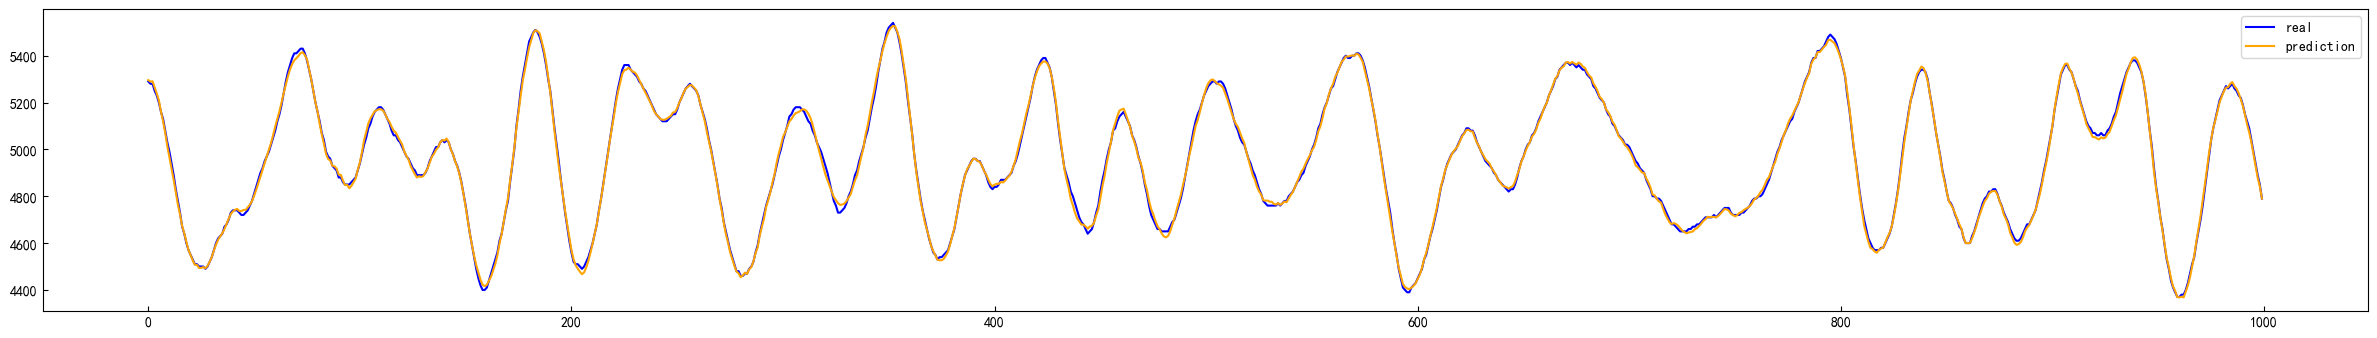

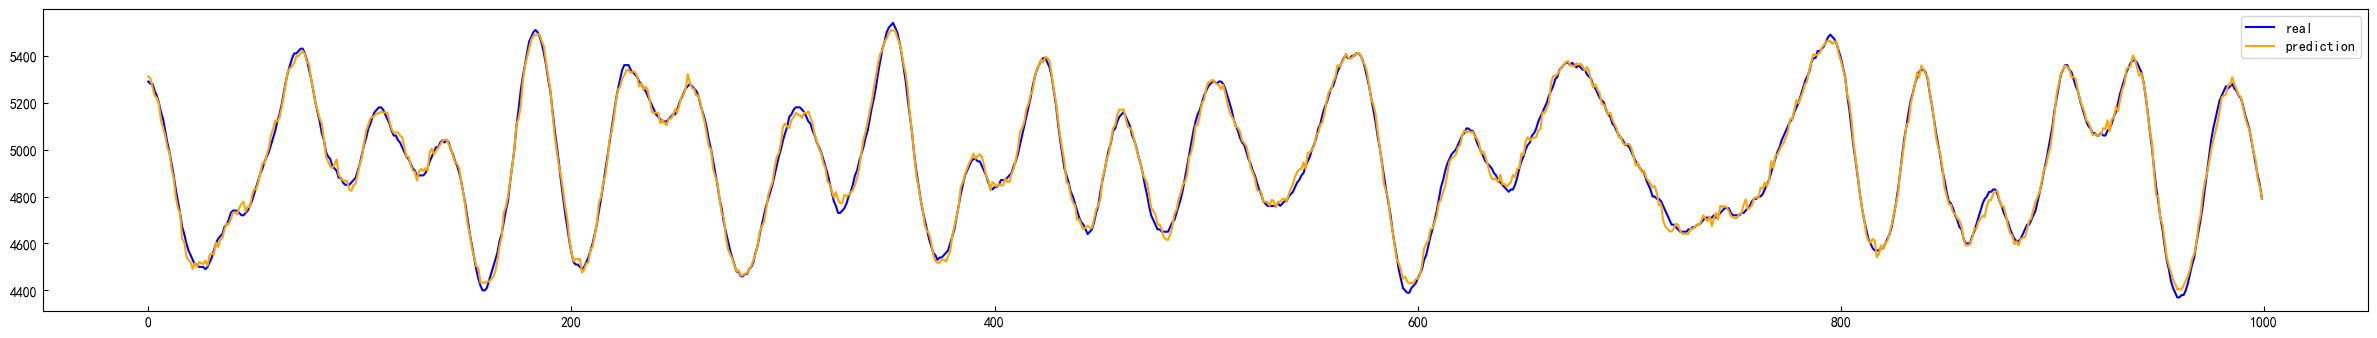

In [31]:
evaluate(valid_y_Force2,N_pre_Y_Force2)
evaluate(valid_y_Force2,H_pre_y_Force2)
print(valid_y_Force2)


print(N_pre_Y_Force2)


print(H_pre_y_Force2)

fan1_force2_real,fan1_force2_pre = FanGuiHua_force2(valid_y_Force2,N_pre_Y_Force2)
np.savetxt('Force2_非线性_NN.csv',np.hstack((fan1_force2_real,fan1_force2_pre)),delimiter=',')
fan2_force2_real,fan2_force2_pre = FanGuiHua_force2(valid_y_Force2,H_pre_y_Force2.reshape(1000,1))
np.savetxt('Force2_非线性_HGBRT.csv',np.hstack((fan2_force2_real,fan2_force2_pre)),delimiter=',')

In [35]:
def campare(first,end):
    value = 100*(end-first)/first
    return print(value,'%')

campare(0.014168143972618888,0.028121138182992864)
campare(0.9975636351902422,0.9957648332844505)

98.4814541505175 %
-0.18031951469928845 %


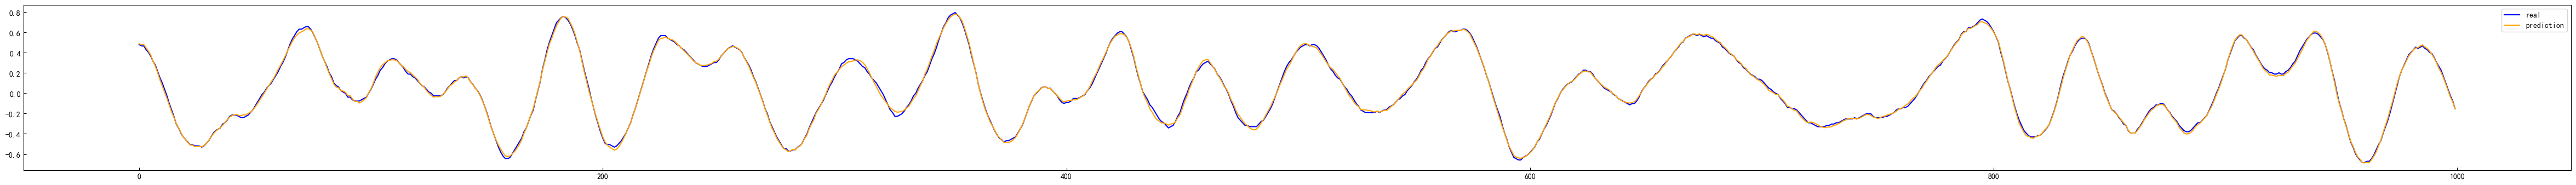

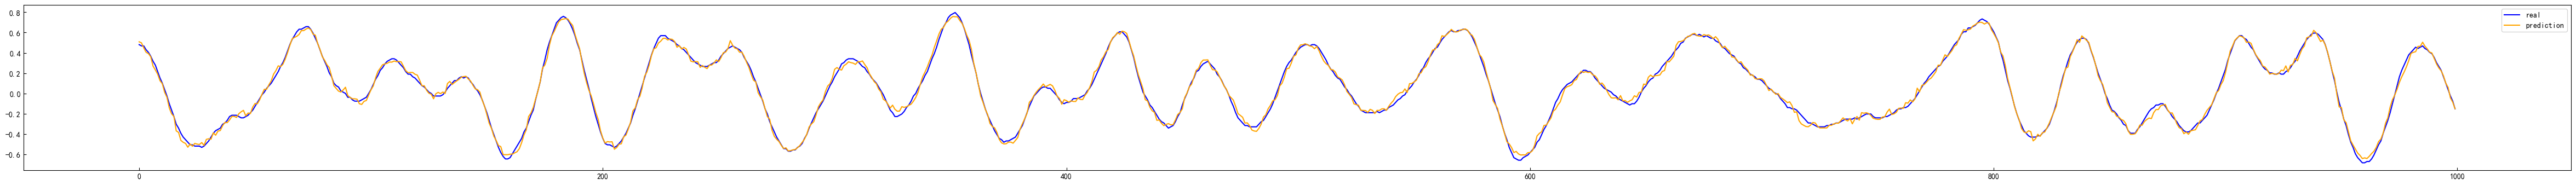

In [22]:
# plt.figure(figsize=(60, 4), dpi=100)
# plt.plot(valid_y_Force2, color='blue', label = 'real')   #真实曲线
# plt.plot(R_pre_Y_Force2, color='orange', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

# plt.figure(figsize=(60, 4), dpi=100)
# plt.plot(valid_y_Force2, color='blue', label = 'real')   #真实曲线
# plt.plot(R_pre_Y_Force2, color='orange', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

plt.figure(figsize=(60, 4), dpi=100)
plt.plot(valid_y_Force2, color='blue', label = 'real')   #真实曲线
plt.plot(N_pre_Y_Force2, color='orange', label = 'prediction') #预测曲线
plt.legend()
plt.show()

plt.figure(figsize=(60, 4), dpi=100)
plt.plot(valid_y_Force2, color='blue', label = 'real')   #真实曲线
plt.plot(H_pre_y_Force2, color='orange', label = 'prediction') #预测曲线
plt.legend()
plt.show()

In [23]:
# 不同输入特征下的效果H,Surge,Pitch,Heave
train_x1, train_y1, valid_x1, valid_y1= split_train_valid(np.hstack((H,Surge,Pitch,Heave)), Force1, 20000, 30000, 31000)

# R_history1, R_pre_train_Y1, R_pre_Y1 = Model_RBF(train_x1, train_y1, valid_x1, valid_y1, feature_number, lr=0.01, epochs=1000, batch_size=256)
N_history1, N_pre_train_Y1, N_pre_Y1 = Model_NN(train_x1, train_y1, valid_x1, valid_y1, 4, lr=0.01, epochs=1000, batch_size=256)
# X_pre_y1, X_best_parameters1 = XGBoost(train_x1, train_y1, valid_x1,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,learning_rate,n_estimators)
H_pre_y1, H_best_parameters1 = HGBRT(train_x1, train_y1, valid_x1,max_depth,max_leaf_nodes,min_samples_leaf)

Train on 10000 samples, validate on 1000 samples
Epoch 1/1000
 - 0s - loss: 0.0035 - val_loss: 3.5821e-04
Epoch 2/1000
 - 0s - loss: 1.2850e-04 - val_loss: 2.7590e-05
Epoch 3/1000
 - 0s - loss: 6.8609e-05 - val_loss: 4.4032e-05
Epoch 4/1000
 - 0s - loss: 7.7662e-05 - val_loss: 2.9210e-05
Epoch 5/1000
 - 0s - loss: 3.7922e-05 - val_loss: 3.0518e-05
Epoch 6/1000
 - 0s - loss: 5.4643e-05 - val_loss: 4.6756e-05
Epoch 7/1000
 - 0s - loss: 8.1026e-05 - val_loss: 8.5017e-05
Epoch 8/1000
 - 0s - loss: 1.1525e-04 - val_loss: 1.0561e-04
Epoch 9/1000
 - 0s - loss: 1.3494e-04 - val_loss: 9.5220e-05
Epoch 10/1000
 - 0s - loss: 1.4695e-04 - val_loss: 6.4502e-05
Epoch 11/1000
 - 0s - loss: 1.4349e-04 - val_loss: 3.6390e-05
Epoch 12/1000
 - 0s - loss: 1.1256e-04 - val_loss: 2.9116e-05
Epoch 13/1000
 - 0s - loss: 8.3120e-05 - val_loss: 3.9943e-05
Epoch 14/1000
 - 0s - loss: 7.5874e-05 - val_loss: 7.0965e-05
Epoch 15/1000
 - 0s - loss: 8.9173e-05 - val_loss: 1.1810e-04
Epoch 16/1000
 - 0s - loss: 1.0890

 - 0s - loss: 3.9042e-05 - val_loss: 2.2524e-05
Epoch 133/1000
 - 0s - loss: 3.8841e-05 - val_loss: 2.2679e-05
Epoch 134/1000
 - 0s - loss: 3.8638e-05 - val_loss: 2.2826e-05
Epoch 135/1000
 - 0s - loss: 3.8439e-05 - val_loss: 2.2965e-05
Epoch 136/1000
 - 0s - loss: 3.8248e-05 - val_loss: 2.3097e-05
Epoch 137/1000
 - 0s - loss: 3.8067e-05 - val_loss: 2.3223e-05
Epoch 138/1000
 - 0s - loss: 3.7899e-05 - val_loss: 2.3345e-05
Epoch 139/1000
 - 0s - loss: 3.7744e-05 - val_loss: 2.3465e-05
Epoch 140/1000
 - 0s - loss: 3.7604e-05 - val_loss: 2.3586e-05
Epoch 141/1000
 - 0s - loss: 3.7479e-05 - val_loss: 2.3710e-05
Epoch 142/1000
 - 0s - loss: 3.7370e-05 - val_loss: 2.3842e-05
Epoch 143/1000
 - 0s - loss: 3.7278e-05 - val_loss: 2.3983e-05
Epoch 144/1000
 - 0s - loss: 3.7206e-05 - val_loss: 2.4137e-05
Epoch 145/1000
 - 0s - loss: 3.7156e-05 - val_loss: 2.4306e-05
Epoch 146/1000
 - 0s - loss: 3.7134e-05 - val_loss: 2.4494e-05
Epoch 147/1000
 - 0s - loss: 3.7146e-05 - val_loss: 2.4703e-05
Epoch 1

Epoch 263/1000
 - 0s - loss: 2.1418e-05 - val_loss: 2.3520e-05
Epoch 264/1000
 - 0s - loss: 2.1758e-05 - val_loss: 2.3522e-05
Epoch 265/1000
 - 0s - loss: 2.2181e-05 - val_loss: 2.3533e-05
Epoch 266/1000
 - 0s - loss: 2.2688e-05 - val_loss: 2.3561e-05
Epoch 267/1000
 - 0s - loss: 2.3272e-05 - val_loss: 2.3611e-05
Epoch 268/1000
 - 0s - loss: 2.3918e-05 - val_loss: 2.3684e-05
Epoch 269/1000
 - 0s - loss: 2.4595e-05 - val_loss: 2.3773e-05
Epoch 270/1000
 - 0s - loss: 2.5255e-05 - val_loss: 2.3868e-05
Epoch 271/1000
 - 0s - loss: 2.5842e-05 - val_loss: 2.3952e-05
Epoch 272/1000
 - 0s - loss: 2.6308e-05 - val_loss: 2.4012e-05
Epoch 273/1000
 - 0s - loss: 2.6623e-05 - val_loss: 2.4043e-05
Epoch 274/1000
 - 0s - loss: 2.6796e-05 - val_loss: 2.4050e-05
Epoch 275/1000
 - 0s - loss: 2.6860e-05 - val_loss: 2.4042e-05
Epoch 276/1000
 - 0s - loss: 2.6859e-05 - val_loss: 2.4029e-05
Epoch 277/1000
 - 0s - loss: 2.6828e-05 - val_loss: 2.4015e-05
Epoch 278/1000
 - 0s - loss: 2.6789e-05 - val_loss: 2.4

 - 0s - loss: 2.1402e-05 - val_loss: 2.4949e-05
Epoch 394/1000
 - 0s - loss: 2.1512e-05 - val_loss: 2.5017e-05
Epoch 395/1000
 - 0s - loss: 2.1644e-05 - val_loss: 2.5065e-05
Epoch 396/1000
 - 0s - loss: 2.1796e-05 - val_loss: 2.5091e-05
Epoch 397/1000
 - 0s - loss: 2.1967e-05 - val_loss: 2.5094e-05
Epoch 398/1000
 - 0s - loss: 2.2154e-05 - val_loss: 2.5076e-05
Epoch 399/1000
 - 0s - loss: 2.2353e-05 - val_loss: 2.5035e-05
Epoch 400/1000
 - 0s - loss: 2.2561e-05 - val_loss: 2.4974e-05
Epoch 401/1000
 - 0s - loss: 2.2772e-05 - val_loss: 2.4893e-05
Epoch 402/1000
 - 0s - loss: 2.2982e-05 - val_loss: 2.4792e-05
Epoch 403/1000
 - 0s - loss: 2.3189e-05 - val_loss: 2.4674e-05
Epoch 404/1000
 - 0s - loss: 2.3389e-05 - val_loss: 2.4538e-05
Epoch 405/1000
 - 0s - loss: 2.3580e-05 - val_loss: 2.4387e-05
Epoch 406/1000
 - 0s - loss: 2.3757e-05 - val_loss: 2.4228e-05
Epoch 407/1000
 - 0s - loss: 2.3909e-05 - val_loss: 2.4074e-05
Epoch 408/1000
 - 0s - loss: 2.4017e-05 - val_loss: 2.3944e-05
Epoch 4

Epoch 524/1000
 - 0s - loss: 4.3980e-05 - val_loss: 2.9642e-05
Epoch 525/1000
 - 0s - loss: 5.0193e-05 - val_loss: 2.9001e-05
Epoch 526/1000
 - 0s - loss: 2.4096e-05 - val_loss: 2.5848e-05
Epoch 527/1000
 - 0s - loss: 2.7439e-05 - val_loss: 3.1314e-05
Epoch 528/1000
 - 0s - loss: 2.8754e-05 - val_loss: 3.2472e-05
Epoch 529/1000
 - 0s - loss: 2.9113e-05 - val_loss: 3.2186e-05
Epoch 530/1000
 - 0s - loss: 2.9618e-05 - val_loss: 3.2578e-05
Epoch 531/1000
 - 0s - loss: 3.0275e-05 - val_loss: 3.2849e-05
Epoch 532/1000
 - 0s - loss: 3.0913e-05 - val_loss: 3.3135e-05
Epoch 533/1000
 - 0s - loss: 3.1462e-05 - val_loss: 3.3398e-05
Epoch 534/1000
 - 0s - loss: 3.1906e-05 - val_loss: 3.3623e-05
Epoch 535/1000
 - 0s - loss: 3.2236e-05 - val_loss: 3.3803e-05
Epoch 536/1000
 - 0s - loss: 3.2473e-05 - val_loss: 3.3944e-05
Epoch 537/1000
 - 0s - loss: 3.2658e-05 - val_loss: 3.4059e-05
Epoch 538/1000
 - 0s - loss: 3.2818e-05 - val_loss: 3.4156e-05
Epoch 539/1000
 - 0s - loss: 3.2984e-05 - val_loss: 3.4

...

Epoch 785/1000
 - 0s - loss: 3.6858e-05 - val_loss: 2.1045e-05
Epoch 786/1000
 - 0s - loss: 4.1325e-05 - val_loss: 2.5412e-05
Epoch 787/1000
 - 0s - loss: 1.9369e-05 - val_loss: 2.2385e-05
Epoch 788/1000
 - 0s - loss: 2.6644e-05 - val_loss: 2.7299e-05
Epoch 789/1000
 - 0s - loss: 3.0971e-05 - val_loss: 2.8364e-05
Epoch 790/1000
 - 0s - loss: 3.6153e-05 - val_loss: 2.2423e-05
Epoch 791/1000
 - 0s - loss: 4.2947e-05 - val_loss: 2.3340e-05
Epoch 792/1000
 - 0s - loss: 1.7361e-05 - val_loss: 2.0441e-05
Epoch 793/1000
 - 0s - loss: 2.4939e-05 - val_loss: 2.6952e-05
Epoch 794/1000
 - 0s - loss: 3.0583e-05 - val_loss: 2.8560e-05
Epoch 795/1000
 - 0s - loss: 3.6122e-05 - val_loss: 2.1143e-05
Epoch 796/1000
 - 0s - loss: 4.2845e-05 - val_loss: 2.5280e-05
Epoch 797/1000
 - 0s - loss: 1.8850e-05 - val_loss: 2.1822e-05
Epoch 798/1000
 - 0s - loss: 2.6210e-05 - val_loss: 2.6972e-05
Epoch 799/1000
 - 0s - loss: 3.0825e-05 - val_loss: 2.8682e-05
Epoch 800/1000
 - 0s - loss: 3.5846e-05 - val_loss: 2.1

 - 0s - loss: 3.5772e-05 - val_loss: 2.1383e-05
Epoch 916/1000
 - 0s - loss: 2.5461e-05 - val_loss: 2.6666e-05
Epoch 917/1000
 - 0s - loss: 2.8384e-05 - val_loss: 2.3801e-05
Epoch 918/1000
 - 0s - loss: 3.0818e-05 - val_loss: 2.4090e-05
Epoch 919/1000
 - 0s - loss: 3.4411e-05 - val_loss: 2.3892e-05
Epoch 920/1000
 - 0s - loss: 4.1124e-05 - val_loss: 1.6195e-05
Epoch 921/1000
 - 0s - loss: 2.0361e-05 - val_loss: 2.4921e-05
Epoch 922/1000
 - 0s - loss: 2.8756e-05 - val_loss: 2.4730e-05
Epoch 923/1000
 - 0s - loss: 3.0336e-05 - val_loss: 2.5381e-05
Epoch 924/1000
 - 0s - loss: 3.1310e-05 - val_loss: 2.2953e-05
Epoch 925/1000
 - 0s - loss: 3.6647e-05 - val_loss: 2.0162e-05
Epoch 926/1000
 - 0s - loss: 2.5253e-05 - val_loss: 2.7448e-05
Epoch 927/1000
 - 0s - loss: 2.7357e-05 - val_loss: 2.4072e-05
Epoch 928/1000
 - 0s - loss: 2.7940e-05 - val_loss: 2.6048e-05
Epoch 929/1000
 - 0s - loss: 2.9256e-05 - val_loss: 2.6065e-05
Epoch 930/1000
 - 0s - loss: 2.9973e-05 - val_loss: 2.6913e-05
Epoch 9

D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Best: -0.007048 using {'max_depth': 13, 'max_leaf_nodes': 43, 'min_samples_leaf': 22}


D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


In [32]:
evaluate(valid_y1,N_pre_Y1)
evaluate(valid_y1,H_pre_y1)

RMSE(sklearn): 0.004399854200792372
Acc: 0.9922309233106374
RMSE(sklearn): 0.008144116827537295
Acc: 0.994482160380115


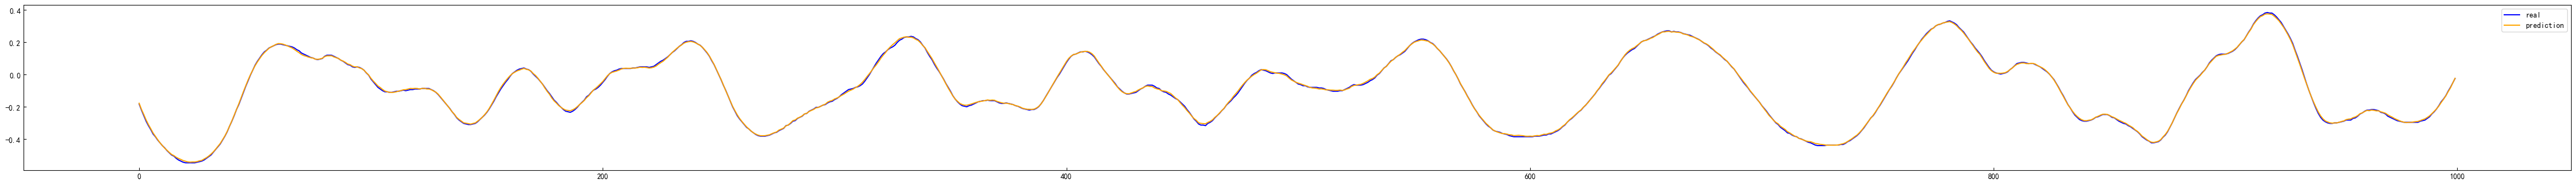

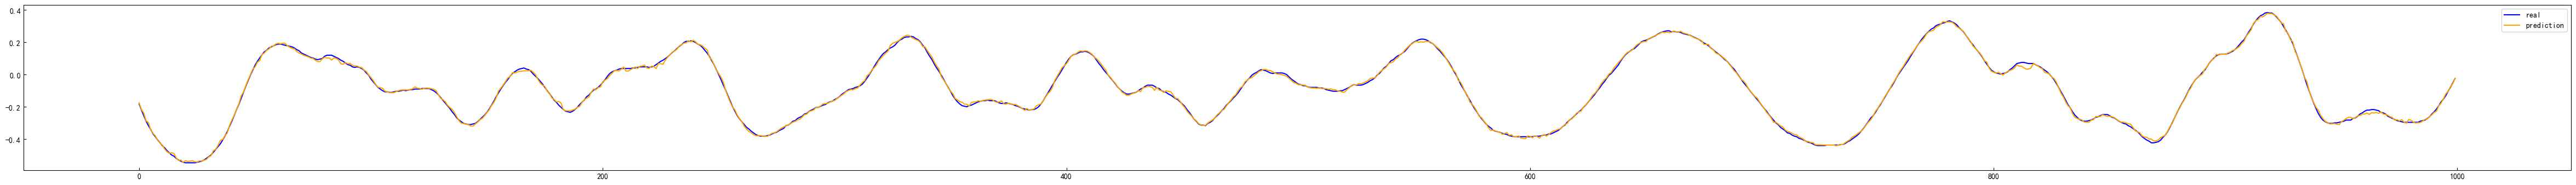

In [25]:
plt.figure(figsize=(60, 4), dpi=100)
plt.plot(valid_y1, color='blue', label = 'real')   #真实曲线
plt.plot(N_pre_Y1, color='orange', label = 'prediction') #预测曲线
plt.legend()
plt.show()

plt.figure(figsize=(60, 4), dpi=100)
plt.plot(valid_y1, color='blue', label = 'real')   #真实曲线
plt.plot(H_pre_y1, color='orange', label = 'prediction') #预测曲线
plt.legend()
plt.show()

In [26]:
# 不同输入特征下的效果H,Surge,Pitch,Heave,Sway,Roll,Yaw
train_x2, train_y2, valid_x2, valid_y2= split_train_valid(np.hstack((H,Surge,Pitch,Heave,Sway,Roll,Yaw)), Force1, 20000, 30000, 31000)

# R_history2, R_pre_train_Y2, R_pre_Y2 = Model_RBF(train_x2, train_y2, valid_x2, valid_y2, feature_number, lr=0.01, epochs=1000, batch_size=256)
N_history2, N_pre_train_Y2, N_pre_Y2 = Model_NN(train_x2, train_y2, valid_x2, valid_y2, 7, lr=0.01, epochs=1000, batch_size=256)
# X_pre_y2, X_best_parameters2 = XGBoost(train_x2, train_y2, valid_x2,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,learning_rate,n_estimators)
H_pre_y2, H_best_parameters2 = HGBRT(train_x2, train_y2, valid_x2,max_depth,max_leaf_nodes,min_samples_leaf)

Train on 10000 samples, validate on 1000 samples
Epoch 1/1000
 - 0s - loss: 0.0067 - val_loss: 6.8865e-04
Epoch 2/1000
 - 0s - loss: 1.7895e-04 - val_loss: 1.8162e-05
Epoch 3/1000
 - 0s - loss: 3.0694e-05 - val_loss: 1.6500e-05
Epoch 4/1000
 - 0s - loss: 2.2297e-05 - val_loss: 9.2502e-06
Epoch 5/1000
 - 0s - loss: 3.9128e-05 - val_loss: 2.4030e-05
Epoch 6/1000
 - 0s - loss: 5.3267e-05 - val_loss: 3.3778e-05
Epoch 7/1000
 - 0s - loss: 4.4139e-05 - val_loss: 1.9309e-05
Epoch 8/1000
 - 0s - loss: 4.7443e-05 - val_loss: 1.2720e-05
Epoch 9/1000
 - 0s - loss: 6.1748e-05 - val_loss: 8.6464e-06
Epoch 10/1000
 - 0s - loss: 5.8906e-05 - val_loss: 1.5110e-05
Epoch 11/1000
 - 0s - loss: 3.6742e-05 - val_loss: 1.1661e-05
Epoch 12/1000
 - 0s - loss: 2.8187e-05 - val_loss: 1.7706e-05
Epoch 13/1000
 - 0s - loss: 3.1919e-05 - val_loss: 2.3732e-05
Epoch 14/1000
 - 0s - loss: 3.4294e-05 - val_loss: 2.1694e-05
Epoch 15/1000
 - 0s - loss: 3.5255e-05 - val_loss: 1.5312e-05
Epoch 16/1000
 - 0s - loss: 3.6440

 - 0s - loss: 1.8947e-05 - val_loss: 9.0838e-06
Epoch 133/1000
 - 0s - loss: 1.8321e-05 - val_loss: 9.0872e-06
Epoch 134/1000
 - 0s - loss: 1.7709e-05 - val_loss: 9.1567e-06
Epoch 135/1000
 - 0s - loss: 1.7143e-05 - val_loss: 9.2939e-06
Epoch 136/1000
 - 0s - loss: 1.6646e-05 - val_loss: 9.4853e-06
Epoch 137/1000
 - 0s - loss: 1.6226e-05 - val_loss: 9.7097e-06
Epoch 138/1000
 - 0s - loss: 1.5876e-05 - val_loss: 9.9509e-06
Epoch 139/1000
 - 0s - loss: 1.5582e-05 - val_loss: 1.0201e-05
Epoch 140/1000
 - 0s - loss: 1.5331e-05 - val_loss: 1.0461e-05
Epoch 141/1000
 - 0s - loss: 1.5114e-05 - val_loss: 1.0734e-05
Epoch 142/1000
 - 0s - loss: 1.4928e-05 - val_loss: 1.1027e-05
Epoch 143/1000
 - 0s - loss: 1.4771e-05 - val_loss: 1.1344e-05
Epoch 144/1000
 - 0s - loss: 1.4645e-05 - val_loss: 1.1691e-05
Epoch 145/1000
 - 0s - loss: 1.4550e-05 - val_loss: 1.2072e-05
Epoch 146/1000
 - 0s - loss: 1.4487e-05 - val_loss: 1.2488e-05
Epoch 147/1000
 - 0s - loss: 1.4456e-05 - val_loss: 1.2938e-05
Epoch 1

Epoch 263/1000
 - 0s - loss: 2.0686e-05 - val_loss: 1.4991e-05
Epoch 264/1000
 - 0s - loss: 2.0596e-05 - val_loss: 1.5273e-05
Epoch 265/1000
 - 0s - loss: 2.0381e-05 - val_loss: 1.5481e-05
Epoch 266/1000
 - 0s - loss: 2.0039e-05 - val_loss: 1.5629e-05
Epoch 267/1000
 - 0s - loss: 1.9639e-05 - val_loss: 1.5748e-05
Epoch 268/1000
 - 0s - loss: 1.9287e-05 - val_loss: 1.5842e-05
Epoch 269/1000
 - 0s - loss: 1.9035e-05 - val_loss: 1.5899e-05
Epoch 270/1000
 - 0s - loss: 1.8863e-05 - val_loss: 1.5919e-05
Epoch 271/1000
 - 0s - loss: 1.8733e-05 - val_loss: 1.5905e-05
Epoch 272/1000
 - 0s - loss: 1.8619e-05 - val_loss: 1.5864e-05
Epoch 273/1000
 - 0s - loss: 1.8510e-05 - val_loss: 1.5801e-05
Epoch 274/1000
 - 0s - loss: 1.8405e-05 - val_loss: 1.5716e-05
Epoch 275/1000
 - 0s - loss: 1.8300e-05 - val_loss: 1.5611e-05
Epoch 276/1000
 - 0s - loss: 1.8189e-05 - val_loss: 1.5484e-05
Epoch 277/1000
 - 0s - loss: 1.8066e-05 - val_loss: 1.5334e-05
Epoch 278/1000
 - 0s - loss: 1.7923e-05 - val_loss: 1.5

 - 0s - loss: 2.6724e-05 - val_loss: 1.7026e-05
Epoch 394/1000
 - 0s - loss: 3.0247e-05 - val_loss: 8.8057e-06
Epoch 395/1000
 - 0s - loss: 2.3876e-05 - val_loss: 1.1086e-05
Epoch 396/1000
 - 0s - loss: 1.9326e-05 - val_loss: 9.0232e-06
Epoch 397/1000
 - 0s - loss: 1.7796e-05 - val_loss: 1.2299e-05
Epoch 398/1000
 - 0s - loss: 3.1466e-05 - val_loss: 1.7084e-05
Epoch 399/1000
 - 0s - loss: 2.2461e-05 - val_loss: 2.0806e-05
Epoch 400/1000
 - 0s - loss: 1.1175e-05 - val_loss: 8.4575e-06
Epoch 401/1000
 - 0s - loss: 1.2920e-05 - val_loss: 9.6644e-06
Epoch 402/1000
 - 0s - loss: 1.1184e-05 - val_loss: 9.0424e-06
Epoch 403/1000
 - 0s - loss: 1.1937e-05 - val_loss: 9.5710e-06
Epoch 404/1000
 - 0s - loss: 1.1574e-05 - val_loss: 9.6882e-06
Epoch 405/1000
 - 0s - loss: 1.1842e-05 - val_loss: 1.0108e-05
Epoch 406/1000
 - 0s - loss: 1.1875e-05 - val_loss: 1.0418e-05
Epoch 407/1000
 - 0s - loss: 1.2087e-05 - val_loss: 1.0801e-05
Epoch 408/1000
 - 0s - loss: 1.2262e-05 - val_loss: 1.1134e-05
Epoch 4

Epoch 524/1000
 - 0s - loss: 1.1346e-05 - val_loss: 8.8670e-06
Epoch 525/1000
 - 0s - loss: 1.1472e-05 - val_loss: 9.2249e-06
Epoch 526/1000
 - 0s - loss: 1.1629e-05 - val_loss: 9.5615e-06
Epoch 527/1000
 - 0s - loss: 1.1811e-05 - val_loss: 9.8679e-06
Epoch 528/1000
 - 0s - loss: 1.2011e-05 - val_loss: 1.0138e-05
Epoch 529/1000
 - 0s - loss: 1.2223e-05 - val_loss: 1.0367e-05
Epoch 530/1000
 - 0s - loss: 1.2440e-05 - val_loss: 1.0552e-05
Epoch 531/1000
 - 0s - loss: 1.2656e-05 - val_loss: 1.0693e-05
Epoch 532/1000
 - 0s - loss: 1.2864e-05 - val_loss: 1.0792e-05
Epoch 533/1000
 - 0s - loss: 1.3058e-05 - val_loss: 1.0851e-05
Epoch 534/1000
 - 0s - loss: 1.3234e-05 - val_loss: 1.0874e-05
Epoch 535/1000
 - 0s - loss: 1.3390e-05 - val_loss: 1.0866e-05
Epoch 536/1000
 - 0s - loss: 1.3522e-05 - val_loss: 1.0832e-05
Epoch 537/1000
 - 0s - loss: 1.3631e-05 - val_loss: 1.0779e-05
Epoch 538/1000
 - 0s - loss: 1.3717e-05 - val_loss: 1.0712e-05
Epoch 539/1000
 - 0s - loss: 1.3782e-05 - val_loss: 1.0

...

Epoch 785/1000
 - 0s - loss: 2.6789e-05 - val_loss: 1.4037e-05
Epoch 786/1000
 - 0s - loss: 3.5667e-05 - val_loss: 1.5492e-05
Epoch 787/1000
 - 0s - loss: 2.4410e-05 - val_loss: 1.1316e-05
Epoch 788/1000
 - 0s - loss: 2.7879e-05 - val_loss: 1.4914e-05
Epoch 789/1000
 - 0s - loss: 3.2528e-05 - val_loss: 1.3049e-05
Epoch 790/1000
 - 0s - loss: 3.8601e-05 - val_loss: 1.3249e-05
Epoch 791/1000
 - 0s - loss: 3.1240e-05 - val_loss: 2.1489e-05
Epoch 792/1000
 - 0s - loss: 4.2671e-05 - val_loss: 3.3582e-05
Epoch 793/1000
 - 0s - loss: 3.6477e-05 - val_loss: 8.4757e-06
Epoch 794/1000
 - 0s - loss: 3.8197e-05 - val_loss: 1.0631e-05
Epoch 795/1000
 - 0s - loss: 4.2279e-05 - val_loss: 1.6604e-05
Epoch 796/1000
 - 0s - loss: 4.1627e-05 - val_loss: 1.6750e-05
Epoch 797/1000
 - 0s - loss: 4.1521e-05 - val_loss: 1.7344e-05
Epoch 798/1000
 - 0s - loss: 3.9373e-05 - val_loss: 2.0121e-05
Epoch 799/1000
 - 0s - loss: 2.2723e-05 - val_loss: 1.7102e-05
Epoch 800/1000
 - 0s - loss: 1.2364e-05 - val_loss: 1.3

 - 0s - loss: 2.6283e-05 - val_loss: 1.4803e-05
Epoch 916/1000
 - 0s - loss: 3.1512e-05 - val_loss: 1.2199e-05
Epoch 917/1000
 - 0s - loss: 3.2330e-05 - val_loss: 9.8733e-06
Epoch 918/1000
 - 0s - loss: 3.5847e-05 - val_loss: 1.8430e-05
Epoch 919/1000
 - 0s - loss: 3.8756e-05 - val_loss: 2.4046e-05
Epoch 920/1000
 - 0s - loss: 4.6966e-05 - val_loss: 2.7425e-05
Epoch 921/1000
 - 0s - loss: 4.3354e-05 - val_loss: 1.9301e-05
Epoch 922/1000
 - 0s - loss: 3.4042e-05 - val_loss: 1.1410e-05
Epoch 923/1000
 - 0s - loss: 2.5013e-05 - val_loss: 1.7597e-05
Epoch 924/1000
 - 0s - loss: 1.3078e-05 - val_loss: 1.2961e-05
Epoch 925/1000
 - 0s - loss: 1.2455e-05 - val_loss: 1.2905e-05
Epoch 926/1000
 - 0s - loss: 1.3382e-05 - val_loss: 1.3380e-05
Epoch 927/1000
 - 0s - loss: 1.3877e-05 - val_loss: 1.3507e-05
Epoch 928/1000
 - 0s - loss: 1.4425e-05 - val_loss: 1.3686e-05
Epoch 929/1000
 - 0s - loss: 1.5033e-05 - val_loss: 1.3944e-05
Epoch 930/1000
 - 0s - loss: 1.5676e-05 - val_loss: 1.4255e-05
Epoch 9

D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Best: -0.006928 using {'max_depth': 15, 'max_leaf_nodes': 43, 'min_samples_leaf': 19}


D:\Anaconda3\envs\TensorFlow_env\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


In [33]:
evaluate(valid_y2,N_pre_Y2)
evaluate(valid_y2,H_pre_y2)

RMSE(sklearn): 0.004084032532456845
Acc: 0.9870170834226444
RMSE(sklearn): 0.0078023842142119215
Acc: 0.9959237715768863


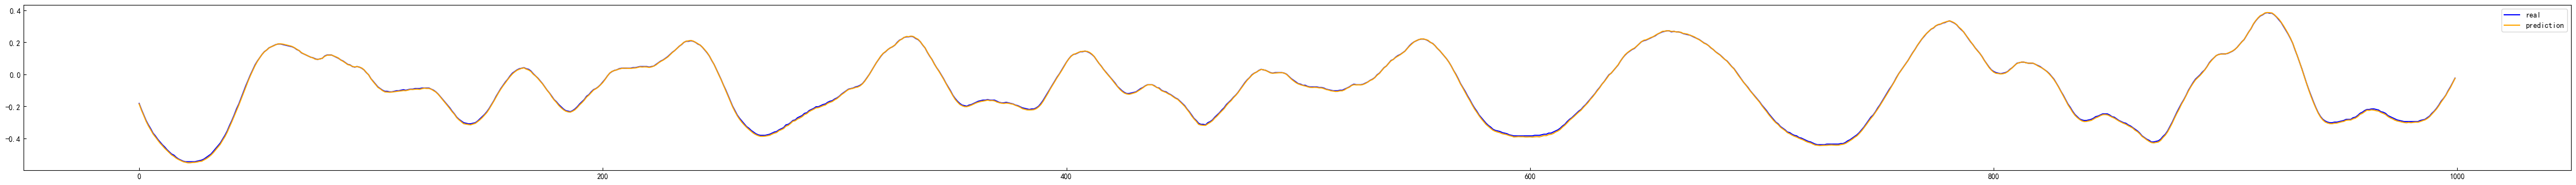

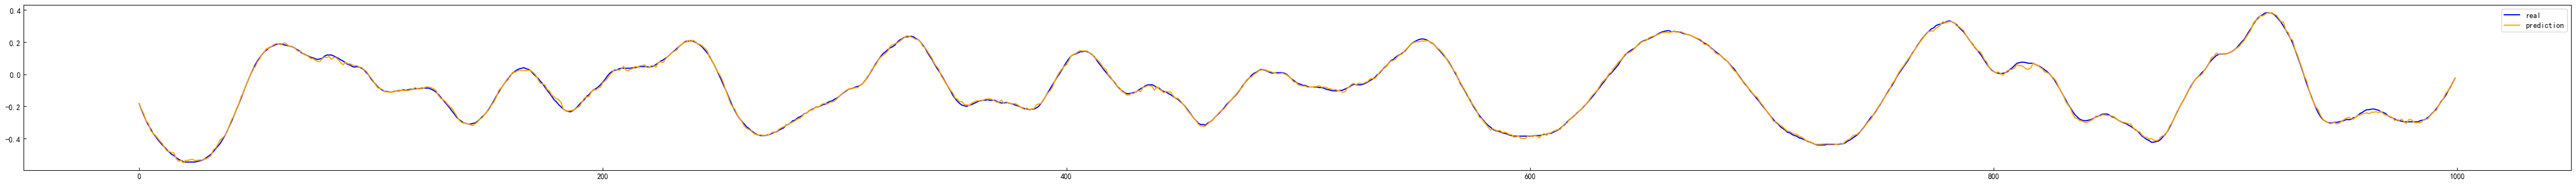

In [28]:
plt.figure(figsize=(60, 4), dpi=100)
plt.plot(valid_y2, color='blue', label = 'real')   #真实曲线
plt.plot(N_pre_Y2, color='orange', label = 'prediction') #预测曲线
plt.legend()
plt.show()

plt.figure(figsize=(60, 4), dpi=100)
plt.plot(valid_y2, color='blue', label = 'real')   #真实曲线
plt.plot(H_pre_y2, color='orange', label = 'prediction') #预测曲线
plt.legend()
plt.show()